# 항공편 지연 예측 — 전처리 설명과 검증
**강사님께 설명할 질문:** 원본에서 어떤 문제가 있었고, 왜 이 처리를 했으며, 무엇이 달라졌는가?

모델을 학습하지 않고 실제 `data/train.csv` 전체와 현재 공통 전처리 함수를 확인한다.
처리 결과는 실측, 처리 목적은 코드 해석, 성능 개선은 미검증으로 구분한다.
기존 Phase 성능표는 전처리 효과의 증거로 사용하지 않는다.

## 1. 범위와 재현 방법
- 모집단: 로컬 원본 CSV 전체. `Delay`가 비어 있는 행은 음성이 아니라 **미라벨**이다.
- 기준: Phase 4의 공통 처리와 Phase 6의 추가 복원/Traffic을 나란히 설명한다.
- 표의 결측은 원칙적으로 pandas `isna()`; 시각 파생은 `-1`도 별도로 센다.
- 원본은 연도·시간대 컬럼이 없어 월/일만으로 실제 날짜와 비행시간을 확정하지 않는다.
- 숫자 스케일링, 이상치 제거, 중복 제거를 했다고 가정하지 않는다. 실제 코드에 있는 처리만 설명한다.

저장소 루트 또는 notebooks 폴더에서 실행. 필요한 추가 도구:
`uv pip install --python .venv/Scripts/python.exe nbformat nbclient nbconvert ipykernel`
실행: `uv run python -m jupyter nbconvert --execute --to notebook --inplace notebooks/preprocessing_walkthrough.ipynb`

In [1]:
from pathlib import Path
import sys, json, hashlib, inspect, gc
from datetime import datetime, timezone
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/features.py').exists())
sys.path.insert(0, str(ROOT))
from src.features import (load_data, impute_cross, build_time_features, restore_time_missing,
    build_traffic_features, build_cyclic_features, encode_categoricals, oof_target_encode,
    smoothed_target_encode, DROP_PRESETS)
from src.cv import CVConfig, make_folds, _make_inner_split
from rerun_all_phases import PHASES, build_features

OUT = ROOT / 'output/preprocessing_review'
OUT.mkdir(parents=True, exist_ok=True)
font_names = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({'font.family': 'Malgun Gothic' if 'Malgun Gothic' in font_names else 'DejaVu Sans',
                     'font.size': 11, 'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, GREY = '#245e91', '#c37726', '#6c7680'
pd.set_option('display.max_columns', 9)
pd.set_option('display.max_rows', 25)
def table(df, name):
    df.to_csv(OUT / f'{name}.csv', index=False, encoding='utf-8-sig')
    display(df)
def figure(fig, name):
    fig.savefig(OUT / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)
def sha(path):
    with path.open('rb') as f: return hashlib.file_digest(f, 'sha256').hexdigest()

path = ROOT / 'data/train.csv'
assert path.exists(), '실제 train.csv가 필요합니다. 합성 데이터로 대체하지 않습니다.'
raw = load_data(path)
N = len(raw)
label_mask = raw.Delay.notna() & raw.Delay.astype('string').str.strip().ne('').fillna(False)
assert set(raw.loc[label_mask, 'Delay']) <= {'Delayed', 'Not_Delayed'}
summary = {'rows': N, 'columns': raw.shape[1], 'labeled': int(label_mask.sum()),
           'unlabeled': int((~label_mask).sum()), 'positive': int(raw.Delay.eq('Delayed').sum())}
summary['positive_rate_labeled'] = summary['positive'] / summary['labeled']
provenance = {'source': 'data/train.csv', 'sha256': sha(path), 'bytes': path.stat().st_size,
              'executed_utc': datetime.now(timezone.utc).isoformat(),
              'versions': {p: version(p) for p in ['pandas','numpy','scikit-learn','lightgbm','matplotlib']},
              'code_sha256': {p: sha(ROOT/p) for p in ['src/features.py','src/cv.py','rerun_all_phases.py']}}
display(pd.DataFrame([summary]))

,rows,columns,labeled,unlabeled,positive,positive_rate_labeled
0,1000000,19,255001,744999,45000,0.17647


## 2. 원본 진단 — 타깃 결측과 피처 결측을 구분한다
아래 사전은 전체 행 기준이다. 고유값 수는 결측을 제외한다. 라벨/미라벨별 결측률은
서로 다른 모집단의 비율이며, 결측 원인이 무작위라는 증거는 아니다.

In [2]:
profile = pd.DataFrame({'컬럼': raw.columns, '자료형': raw.dtypes.astype(str).values,
    '결측_행': raw.isna().sum().values, '결측률_pct': raw.isna().mean().values * 100,
    '고유값_결측제외': raw.nunique(dropna=True).values,
    '라벨행_결측률_pct': raw.loc[label_mask].isna().mean().values * 100,
    '미라벨행_결측률_pct': raw.loc[~label_mask].isna().mean().values * 100})
table(profile.round(3), 'raw_column_profile')
summary['duplicate_id'] = int(raw.ID.duplicated().sum())
summary['duplicate_rows_exact'] = int(raw.duplicated().sum())
summary['duplicate_predictors_without_id'] = int(raw.drop(columns=['ID','Delay']).duplicated().sum())
summary['constant_columns'] = raw.columns[raw.nunique(dropna=False).eq(1)].tolist()
display(Markdown(f"ID 중복 **{summary['duplicate_id']:,}행**, 완전 중복 **{summary['duplicate_rows_exact']:,}행**, "
                 f"ID·Delay 제외 피처 중복 **{summary['duplicate_predictors_without_id']:,}행**. "
                 f"상수 컬럼: **{', '.join(summary['constant_columns'])}**. 중복은 제거하지 않았다."))

,컬럼,자료형,결측_행,결측률_pct,고유값_결측제외,라벨행_결측률_pct,미라벨행_결측률_pct
0,ID,str,0,0.000,1000000,0.000,0.000
1,Month,int64,0,0.000,12,0.000,0.000
2,Day_of_Month,int64,0,0.000,31,0.000,0.000
3,Estimated_Departure_Time,float64,109019,10.902,1365,10.918,10.896
4,Estimated_Arrival_Time,float64,109040,10.904,1428,10.856,10.920
5,Cancelled,int64,0,0.000,1,0.000,0.000
6,Diverted,int64,0,0.000,1,0.000,0.000
7,Origin_Airport,str,0,0.000,374,0.000,0.000
8,Origin_Airport_ID,int64,0,0.000,374,0.000,0.000
9,Origin_State,str,109015,10.902,52,10.924,10.894


ID 중복 **0행**, 완전 중복 **0행**, ID·Delay 제외 피처 중복 **0행**. 상수 컬럼: **Cancelled, Diverted**. 중복은 제거하지 않았다.

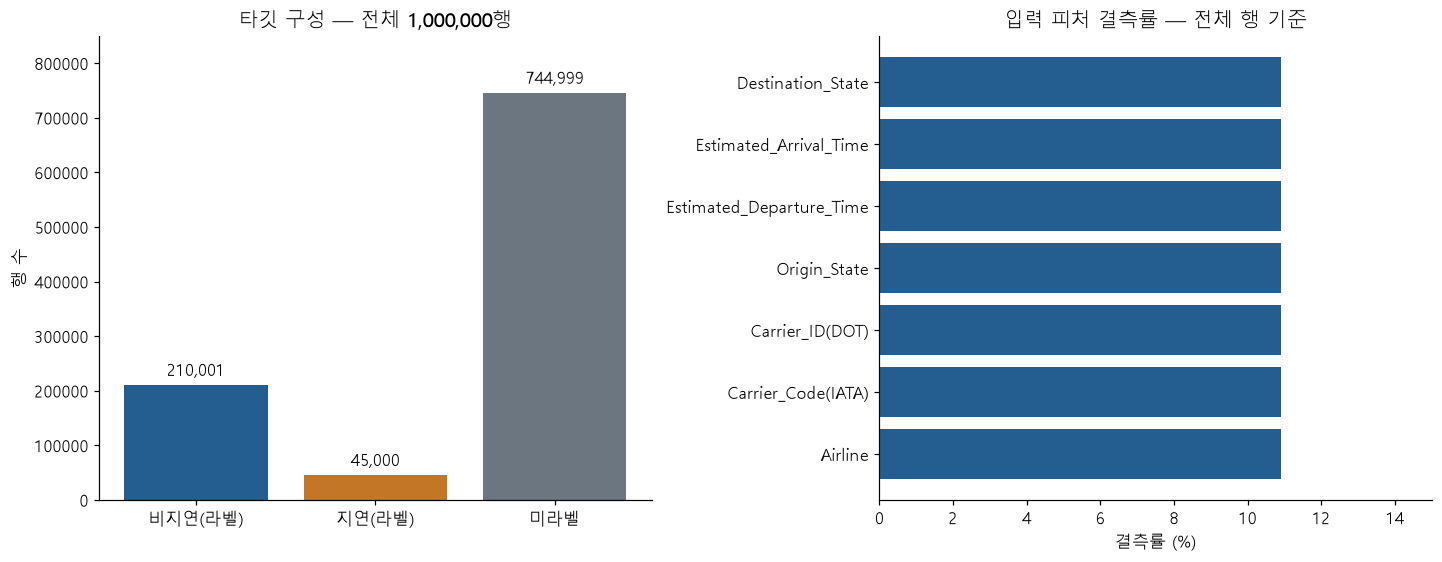

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')
counts = [summary['labeled']-summary['positive'], summary['positive'], summary['unlabeled']]
bars = axes[0].bar(['비지연(라벨)', '지연(라벨)', '미라벨'], counts, color=[BLUE, ORANGE, GREY])
axes[0].bar_label(bars, labels=[f'{v:,}' for v in counts], padding=4)
axes[0].set(title=f'타깃 구성 — 전체 {N:,}행', ylabel='행 수', ylim=(0,max(counts)*1.14))
missing = profile.query("컬럼 != 'Delay' and 결측_행 > 0").sort_values('결측률_pct')
axes[1].barh(missing['컬럼'], missing['결측률_pct'], color=BLUE)
axes[1].set(title='입력 피처 결측률 — 전체 행 기준', xlabel='결측률 (%)', xlim=(0,15))
figure(fig, '01_raw_missing_target')

## 3. 교차 결측 대치 — 실제로 일대일 매핑인가?
`impute_cross`는 관측된 key→value의 **첫 번째 값**으로 사전을 만들고 결측을 채운다.
Phase 4는 정방향, Phase 1은 역방향도 적용한다. 이것은 평균 대치가 아니다.
키에 여러 값이 연결되면 어떤 값이 맞는지 확정할 수 없다. 함수 설명의 일대일 가정을 전수 점검한다.

In [4]:
pairs = [('Carrier_Code(IATA)','Airline'), ('Origin_Airport','Origin_State'),
         ('Destination_Airport','Destination_State')]
mapping_records=[]
for key, val in pairs:
    for a,b in [(key,val),(val,key)]:
        known=raw.dropna(subset=[a,b])
        multiplicity=known.groupby(a, observed=True)[b].nunique()
        ambiguous=multiplicity[multiplicity>1].index
        mapping_records.append({'방향':f'{a} → {b}', '관측_키':len(multiplicity),
            '충돌_키':len(ambiguous), '결측대상_행':int(raw[b].isna().sum()),
            '충돌키로_채울수있는_행':int((raw[b].isna() & raw[a].isin(ambiguous)).sum())})
mapping = pd.DataFrame(mapping_records)
table(mapping, 'mapping_integrity')
forward = impute_cross(raw)
bidirectional = impute_cross(raw, bidirectional=True)
cols=['Airline','Carrier_Code(IATA)','Origin_State','Destination_State']
fill = pd.DataFrame({'컬럼':cols, '원본_결측':raw[cols].isna().sum().values,
                    '정방향후_결측':forward[cols].isna().sum().values,
                    '양방향후_결측':bidirectional[cols].isna().sum().values})
table(fill,'cross_imputation_before_after')
summary['airline_missing_before']=int(raw.Airline.isna().sum())
summary['airline_missing_after']=int(forward.Airline.isna().sum())
summary['mapping_ambiguous_fill']=int(mapping.iloc[0]['충돌키로_채울수있는_행'])
known=raw.dropna(subset=['Carrier_Code(IATA)','Airline'])
amb=known.groupby('Carrier_Code(IATA)',observed=True).Airline.nunique()
amb_codes=amb[amb>1].index
display(known[known['Carrier_Code(IATA)'].isin(amb_codes)][['Carrier_Code(IATA)','Airline']].drop_duplicates().head(15))
# 입력 순서 의존성을 실제 원본의 역순으로 확인 (정방향).
reversed_fill=impute_cross(raw.iloc[::-1]).sort_index()
affected=raw.Airline.isna() & forward.Airline.notna()
summary['airline_order_sensitive_rows']=int((forward.loc[affected,'Airline'] != reversed_fill.loc[affected,'Airline']).sum())
display(Markdown(f"원본 행 순서만 뒤집었을 때, 대치된 Airline이 달라진 행: **{summary['airline_order_sensitive_rows']:,}행**. "
                 '이는 처리의 순서 의존성 실측이며, 어느 항공사명이 정답인지는 원천 코드 사전 확인이 필요하다.'))
del bidirectional, reversed_fill, known
gc.collect();

,방향,관측_키,충돌_키,결측대상_행,충돌키로_채울수있는_행
0,Carrier_Code(IATA) → Airline,11,5,108920,66448
1,Airline → Carrier_Code(IATA),28,7,108990,21209
2,Origin_Airport → Origin_State,374,0,109015,0
3,Origin_State → Origin_Airport,52,50,0,0
4,Destination_Airport → Destination_State,374,0,109079,0
5,Destination_State → Destination_Airport,52,50,0,0


,컬럼,원본_결측,정방향후_결측,양방향후_결측
0,Airline,108920,11864,11864
1,Carrier_Code(IATA),108990,108990,11864
2,Origin_State,109015,0,0
3,Destination_State,109079,1,1


,Carrier_Code(IATA),Airline
1,UA,SkyWest Airlines Inc.
2,AA,American Airlines Inc.
3,UA,United Air Lines Inc.
5,UA,Republic Airlines
9,UA,ExpressJet Airlines Inc.
10,AA,Republic Airlines
11,DL,Delta Air Lines Inc.
22,UA,Air Wisconsin Airlines Corp
25,AS,Horizon Air
29,AS,Alaska Airlines Inc.


원본 행 순서만 뒤집었을 때, 대치된 Airline이 달라진 행: **27,536행**. 이는 처리의 순서 의존성 실측이며, 어느 항공사명이 정답인지는 원천 코드 사전 확인이 필요하다.

## 4. HHMM → 시·분 → 시간차
`0930 → 9시 30분`처럼 100진 표기를 분으로 바꾼 뒤 계산한다.
도착 시각이 출발보다 작으면 1,440분을 더한다. 양쪽 중 하나라도 없으면 Duration은 NaN이다.
현재 기본값 `strict=False`를 그대로 사용하며, 엄격한 파싱은 진단만 한다.
**Duration은 현지 시각 차이의 proxy**다. 자정 보정은 시간대 보정을 대신하지 않는다.

In [5]:
forward['Route']=forward.Origin_Airport.astype(str)+'_'+forward.Destination_Airport.astype(str)
times=build_time_features(forward,keep_minute=True)
time_checks=[]
for c in ['Estimated_Departure_Time','Estimated_Arrival_Time']:
    v=pd.to_numeric(raw[c],errors='coerce')
    invalid=v.notna() & ((v<0) | (v//100>23) | (v%100>59) | (v%1!=0))
    time_checks.append({'컬럼':c, '결측':int(v.isna().sum()), '엄격범위외':int(invalid.sum()),
                        '2400_행':int(v.eq(2400).sum()),'분60이상_행':int((v%100>=60).sum())})
table(pd.DataFrame(time_checks),'hhmm_checks')
duration=times.Estimated_Duration
summary.update(duration_missing=int(duration.isna().sum()), duration_zero=int(duration.eq(0).sum()),
               duration_over_12h=int(duration.gt(720).sum()))
valid=(times.Dep_Hour>=0)&(times.Arr_Hour>=0)
wrapped=valid & ((times.Arr_Hour*60+times.Arr_Minute)<(times.Dep_Hour*60+times.Dep_Minute))
summary['midnight_wrap_rows']=int(wrapped.sum())
example_ids=list(times.index[wrapped][:2])+list(times.index[times.Dep_Hour.eq(-1) & times.Arr_Hour.ge(0)][:2])
table(times.loc[example_ids,['ID','Estimated_Departure_Time','Estimated_Arrival_Time',
    'Dep_Hour','Dep_Minute','Arr_Hour','Arr_Minute','Estimated_Duration']].reset_index(drop=True),'time_examples')
display(duration.describe(percentiles=[.01,.5,.95,.99]).to_frame('시간차_proxy_분').round(2))
display(Markdown(f"0분 **{summary['duration_zero']:,}행**, 12시간 초과 **{summary['duration_over_12h']:,}행**, "
                 f"자정 보정 **{summary['midnight_wrap_rows']:,}행**. 이들은 검토 후보이며 자동 삭제하지 않았다."))

,컬럼,결측,엄격범위외,2400_행,분60이상_행
0,Estimated_Departure_Time,109019,0,0,0
1,Estimated_Arrival_Time,109040,13,13,0


,ID,Estimated_Departure_Time,Estimated_Arrival_Time,Dep_Hour,Dep_Minute,Arr_Hour,Arr_Minute,Estimated_Duration
0,TRAIN_000033,2158.0,545.0,21,58,5,45,467.0
1,TRAIN_000038,2350.0,555.0,23,50,5,55,365.0
2,TRAIN_000025,NaN,2020.0,-1,-1,20,20,NaN
3,TRAIN_000074,NaN,749.0,-1,-1,7,49,NaN


,시간차_proxy_분
count,793629.00
mean,140.69
std,101.71
min,0.00
1%,21.00
50%,113.00
95%,341.00
99%,502.00
max,1439.00


0분 **370행**, 12시간 초과 **1,122행**, 자정 보정 **26,802행**. 이들은 검토 후보이며 자동 삭제하지 않았다.

## 5. Phase 6 결측 복원 — Route 중앙값 → 전역 중앙값 → 단측 시간 역산
관측 시간차의 Route 중앙값을 먼저 사용하고 없으면 전역 중앙값으로 채운다.
한쪽 시각만 없을 때 다른 쪽과 Duration으로 역산한다. **양쪽 시각이 모두 없으면 시각은 복원되지 않는다.**
중앙값은 현재 라벨+미라벨 전체에서 계산한다. 타깃을 사용하지 않지만, 학습 데이터만으로
통계를 적합하는 inductive 방식은 아니다. 배포 시 같은 범위의 스케줄을 얻을 수 있는지는 별도 검증한다.

,항목,복원전,복원후
0,Duration NaN,206371,0
1,출발시간 -1,109019,11688
2,도착시간 -1,109040,11688


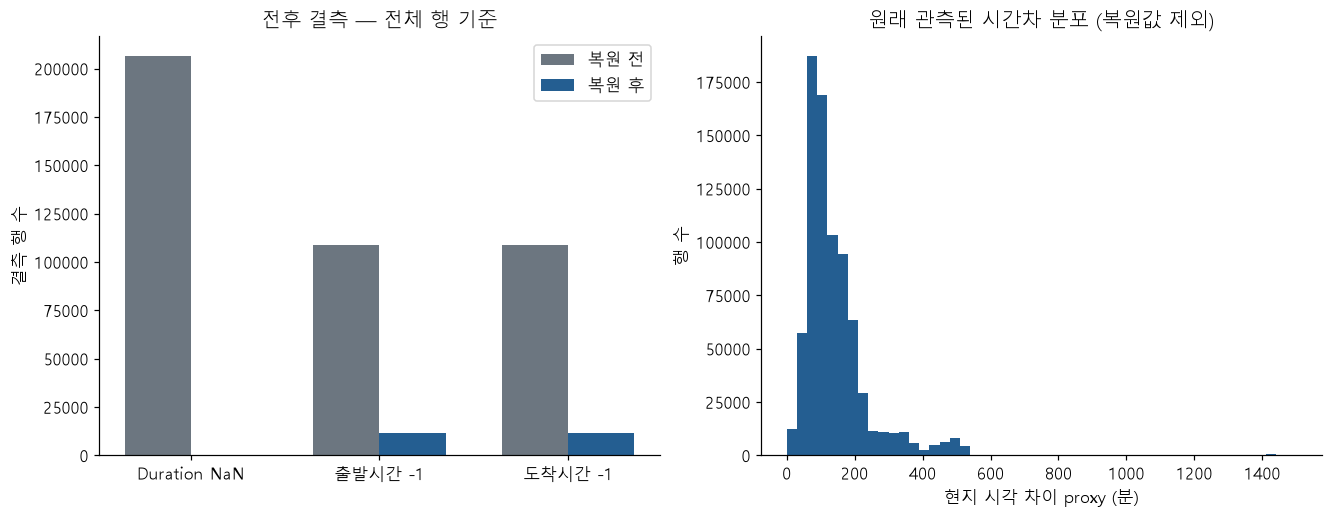

Duration 복원: Route 중앙값 **206,335행**, 전역 fallback **36행**. 양쪽 시간이 없는 **11,688행**의 시각은 여전히 미상이다.

In [6]:
route_median=times.groupby('Route',observed=True).Estimated_Duration.transform('median')
miss=duration.isna()
route_filled=int((miss & route_median.notna()).sum())
global_filled=int((miss & route_median.isna()).sum())
restored=restore_time_missing(times)
restore_table=pd.DataFrame({'항목':['Duration NaN','출발시간 -1','도착시간 -1'],
    '복원전':[int(duration.isna().sum()),int(times.Dep_Hour.eq(-1).sum()),int(times.Arr_Hour.eq(-1).sum())],
    '복원후':[int(restored.Estimated_Duration.isna().sum()),int(restored.Dep_Hour.eq(-1).sum()),int(restored.Arr_Hour.eq(-1).sum())]})
table(restore_table,'time_restoration')
summary.update(route_median_filled=route_filled,global_median_filled=global_filled,
               hours_both_missing=int((times.Dep_Hour.eq(-1)&times.Arr_Hour.eq(-1)).sum()))
assert route_filled+global_filled==int(miss.sum())
assert restored.Estimated_Duration.notna().all()
assert restored.Dep_Hour.eq(-1).sum()==summary['hours_both_missing']
assert restored.Arr_Hour.eq(-1).sum()==summary['hours_both_missing']
fig,axes=plt.subplots(1,2,figsize=(12,4.6),layout='constrained')
x=np.arange(3); width=.35
axes[0].bar(x-width/2,restore_table['복원전'],width,label='복원 전',color=GREY)
axes[0].bar(x+width/2,restore_table['복원후'],width,label='복원 후',color=BLUE)
axes[0].set(xticks=x,xticklabels=restore_table['항목'],ylabel='결측 행 수',title='전후 결측 — 전체 행 기준')
axes[0].legend()
axes[1].hist(duration.dropna(),bins=np.arange(0,1501,30),color=BLUE)
axes[1].set(title='원래 관측된 시간차 분포 (복원값 제외)',xlabel='현지 시각 차이 proxy (분)',ylabel='행 수')
figure(fig,'02_time_restoration')
display(Markdown(f"Duration 복원: Route 중앙값 **{route_filled:,}행**, 전역 fallback **{global_filled:,}행**. "
                 f"양쪽 시간이 없는 **{summary['hours_both_missing']:,}행**의 시각은 여전히 미상이다."))

## 6. 순환 인코딩과 Speed proxy
Sin/Cos는 23시와 0시가 인접한 시간임을 표현한다. Phase 4는 결측을 NaN으로,
Phase 6의 기존 설정은 남은 결측을 **순환 피처에서만 정오(12시)**로 취급한다.
이것은 실제 시각을 알아낸 것이 아니다. `Air_Speed_Proxy = Distance / (Duration + 1e-5)`이며
거리 단위·시간대가 검증되지 않았으므로 물리적 속도라고 부르지 않는다.

,통계,Distance,Duration_restored,Speed_proxy
0,count,1000000.000000,1000000.000000,1.000000e+06
1,mean,784.078499,140.568475,6.711189e+03
2,std,590.790469,101.599098,3.705842e+05
3,min,16.000000,0.000000,5.837387e-02
4,1%,89.000000,22.000000,1.487179e+00
5,50%,623.000000,112.000000,4.757142e+00
6,99%,2586.000000,503.000000,2.034782e+01
7,max,5095.000000,1439.000000,7.580000e+07


Phase 6에서 **11,688행**이 결측임에도 정오의 Sin/Cos를 갖는다. 0분 Duration이 존재하면 작은 epsilon은 0으로 나누는 오류만 피하고 큰 proxy 값은 남긴다.

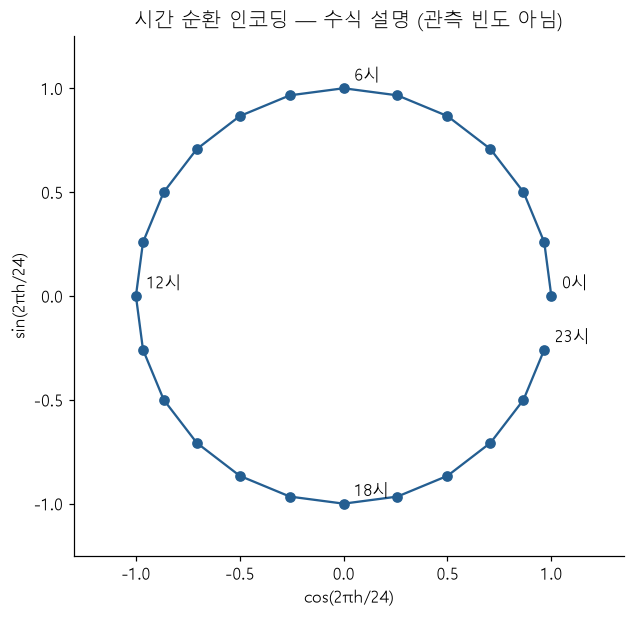

In [7]:
cyclic4=build_cyclic_features(times)
cyclic6=build_cyclic_features(restored,missing='noon')
summary['p6_noon_encoded_missing']=int(restored.Dep_Hour.eq(-1).sum())
speed=restored.Distance/(restored.Estimated_Duration+1e-5)
summary['speed_proxy_max']=float(speed.max())
numeric_summary=pd.DataFrame({'Distance':raw.Distance.describe(percentiles=[.01,.5,.99]),
    'Duration_restored':restored.Estimated_Duration.describe(percentiles=[.01,.5,.99]),
    'Speed_proxy':speed.describe(percentiles=[.01,.5,.99])})
table(numeric_summary.rename_axis('통계').reset_index(),'numeric_diagnostics')
display(Markdown(f"Phase 6에서 **{summary['p6_noon_encoded_missing']:,}행**이 결측임에도 정오의 Sin/Cos를 갖는다. "
                 '0분 Duration이 존재하면 작은 epsilon은 0으로 나누는 오류만 피하고 큰 proxy 값은 남긴다.'))
hours=pd.DataFrame({'Dep_Hour':np.arange(24)})
unit=build_cyclic_features(hours)
fig,ax=plt.subplots(figsize=(6.5,5.5),layout='constrained')
ax.plot(unit.Cos_Dep_Hour,unit.Sin_Dep_Hour,color=BLUE,marker='o')
for h in [0,6,12,18,23]:
    ax.annotate(f'{h}시',(unit.Cos_Dep_Hour[h],unit.Sin_Dep_Hour[h]),xytext=(7,5),textcoords='offset points')
ax.set(xlabel='cos(2πh/24)',ylabel='sin(2πh/24)',title='시간 순환 인코딩 — 수식 설명 (관측 빈도 아님)',xlim=(-1.3,1.35),ylim=(-1.25,1.25))
ax.set_aspect('equal'); figure(fig,'03_cyclic_encoding')
del cyclic4,cyclic6
gc.collect();

## 7. Traffic — 실제 혼잡도인가, 표본에서 센 편수인가?
월×일×공항×시간대별 **데이터 내 행 수**다. 항공편 전체 모집단이 아니면 실제 공항 운항 편수와 다르다.
미상 시간(-1)을 한 시간대로 세면 결측 밀도가 된다. 같은 복원 데이터를 입력해
legacy 집계와 결측 제외 집계만 비교한다. 이 비교에는 모델 성능 해석이 없다.

,피처,시각미상_행,legacy_미상행_중앙값,legacy_미상행_최대,fixed_미상행_NaN
0,Origin_Traffic,11688,1.0,8.0,11688
1,Dest_Traffic,11688,1.0,7.0,11688


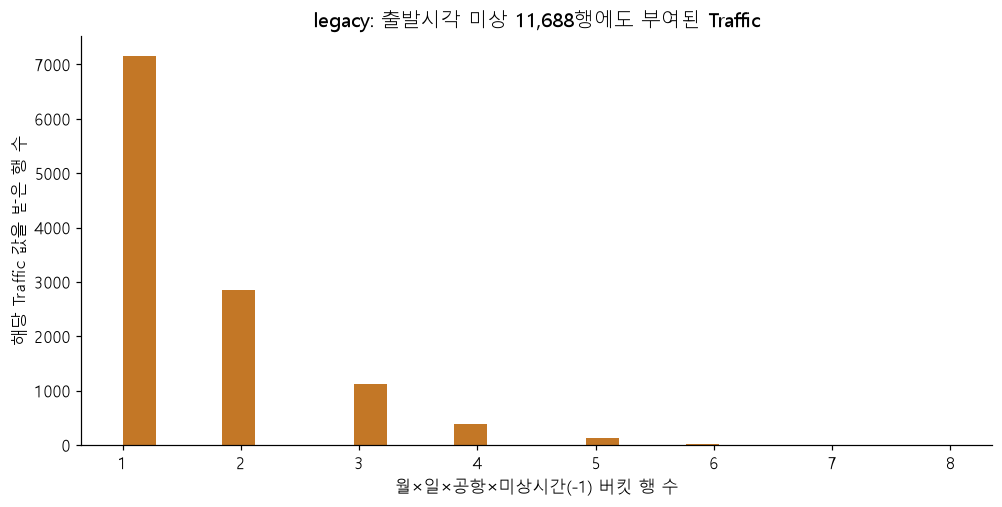

In [8]:
legacy=build_traffic_features(restored,exclude_missing_hour=False,add_missing_flag=False)
fixed=build_traffic_features(restored,exclude_missing_hour=True,add_missing_flag=True)
traffic_records=[]
for hour, traffic, flag in [('Dep_Hour','Origin_Traffic','Origin_Hour_Missing'),
                          ('Arr_Hour','Dest_Traffic','Dest_Hour_Missing')]:
    missing=restored[hour].eq(-1)
    traffic_records.append({'피처':traffic,'시각미상_행':int(missing.sum()),
        'legacy_미상행_중앙값':float(legacy.loc[missing,traffic].median()),
        'legacy_미상행_최대':float(legacy.loc[missing,traffic].max()),
        'fixed_미상행_NaN':int(fixed.loc[missing,traffic].isna().sum())})
    assert fixed.loc[missing,traffic].isna().all()
    assert fixed.loc[~missing,traffic].equals(legacy.loc[~missing,traffic])
    assert int(fixed[flag].sum())==int(missing.sum())
traffic_table=pd.DataFrame(traffic_records)
table(traffic_table,'traffic_missing_comparison')
summary['traffic']=traffic_records
fig,ax=plt.subplots(figsize=(9,4.5),layout='constrained')
mask=restored.Dep_Hour.eq(-1)
ax.hist(legacy.loc[mask,'Origin_Traffic'],bins=25,color=ORANGE)
ax.set(title=f'legacy: 출발시각 미상 {int(mask.sum()):,}행에도 부여된 Traffic',
       xlabel='월×일×공항×미상시간(-1) 버킷 행 수',ylabel='해당 Traffic 값을 받은 행 수')
figure(fig,'04_traffic_missing_bucket')
# 단일 실제 그룹을 원시 행 필터로 독립 검산한다.
row=fixed.loc[~mask].iloc[0]
group=(restored.Month.eq(row.Month)&restored.Day_of_Month.eq(row.Day_of_Month)&
       restored.Origin_Airport.eq(row.Origin_Airport)&restored.Dep_Hour.eq(row.Dep_Hour))
assert int(group.sum())==int(row.Origin_Traffic)
del legacy,fixed
gc.collect();

## 8. 컬럼 제거·범주형 — 정리와 성능 가설을 구분한다
ID·상수 제거는 데이터 성질로 설명할 수 있다. State, Day_of_Month, 분 단위 등 제거의
성능상 이점은 별도 ablation이 필요하다. LightGBM 입력에서 category dtype을 유지한다.
정수 인코딩은 범주의 크기 순서를 뜻하지 않는다. 현재는 라벨+미라벨 vocabulary를 함께 적합한다.

In [9]:
drop_table=pd.DataFrame([{'컬럼':c, **{p:('제거' if c in cols else '유지') for p,cols in DROP_PRESETS.items()}}
                        for c in dict.fromkeys(c for cols in DROP_PRESETS.values() for c in cols)])
table(drop_table,'drop_presets')
feature_rows=[]
for spec in PHASES:
    X,y,U=build_features(raw,spec)
    cat_present=[c for c in spec.cat_cols if c in X]
    model_cols=list(X.columns)
    if spec.te:
        model_cols += ['TE_'+c for c in cat_present]
        if spec.te_drop_original: model_cols=[c for c in model_cols if c not in cat_present]
    feature_rows.append({'Phase':spec.key,'라벨행':len(X),'미라벨행':len(U),
        '기본피처수':X.shape[1],'TE후_예상피처수':len(model_cols),
        '시간복원':spec.restore_hours,'Traffic':spec.traffic,'pseudo':spec.pseudo or '-',
        '최종컬럼':', '.join(model_cols)})
    assert len(X)==summary['labeled'] and len(U)==summary['unlabeled']
    if spec.key=='P4': X4,y4,U4=X,y,U
    del X,y,U
    gc.collect()
feature_table=pd.DataFrame(feature_rows)
feature_table.to_csv(OUT/'phase_feature_inventory.csv',index=False,encoding='utf-8-sig')
display(feature_table.drop(columns=['최종컬럼']))
display(Markdown('행 수를 보존했으며, 위 반복은 **build_features만 호출**했다. Teacher/student 모델은 학습하지 않았다. '
                 '기본피처에는 원본 Estimated_Departure_Time/Arrival_Time도 남아 있는지 최종컬럼 CSV로 확인할 수 있다.'))

,컬럼,baseline,pruned,advanced
0,ID,제거,제거,제거
1,Cancelled,제거,제거,제거
2,Diverted,제거,제거,제거
3,Origin_Airport_ID,제거,제거,제거
4,Destination_Airport_ID,제거,제거,제거
5,Carrier_ID(DOT),제거,제거,제거
6,Carrier_Code(IATA),유지,제거,제거
7,Origin_State,유지,제거,제거
8,Destination_State,유지,제거,제거
9,Day_of_Month,유지,제거,제거


,Phase,라벨행,미라벨행,기본피처수,TE후_예상피처수,시간복원,Traffic,pseudo
0,P1,255001,744999,21,21,False,False,-
1,P2,255001,744999,14,14,False,False,-
2,P3,255001,744999,15,15,False,False,-
3,P4,255001,744999,15,20,False,False,-
4,P4_te0,255001,744999,15,20,False,False,-
5,P4_nospw,255001,744999,15,20,False,False,-
6,P5_leaky,255001,744999,15,20,False,False,leaky
7,P5_honest,255001,744999,15,20,False,False,honest
8,P6_legacy,255001,744999,17,22,True,True,-
9,P6_fixed,255001,744999,19,24,True,True,-


행 수를 보존했으며, 위 반복은 **build_features만 호출**했다. Teacher/student 모델은 학습하지 않았다. 기본피처에는 원본 Estimated_Departure_Time/Arrival_Time도 남아 있는지 최종컬럼 CSV로 확인할 수 있다.

## 9. TE — 검증 정답을 피처에 섞지 않는 법
`(그룹합 + m × 학습 전체 지연율) / (그룹건수 + m)`, m=20.
작은 그룹은 전체 평균 쪽으로 수축하고 미관측 범주는 학습 평균을 사용한다.
실제 P4 라벨 데이터 fold 1의 outer-train을 다시 80/20으로 나눈다.
학습행은 내부 5-fold OOF TE, holdout과 outer-valid는 inner-train 라벨만으로 인코딩한다.
아래는 TE만 계산하며 트리를 학습하지 않는다.

,key,size,mean,sum,smooth
0,3808,1,0.0,0,0.16807
1,4828,1,0.0,0,0.16807
2,4241,1,0.0,0,0.16807
3,4489,1,0.0,0,0.16807
4,3139,1,0.0,0,0.16807
5,4648,1,0.0,0,0.16807
6,4652,1,1.0,1,0.21569
7,4090,1,1.0,1,0.21569
8,4108,1,1.0,1,0.21569
9,1777,1,0.0,0,0.16807


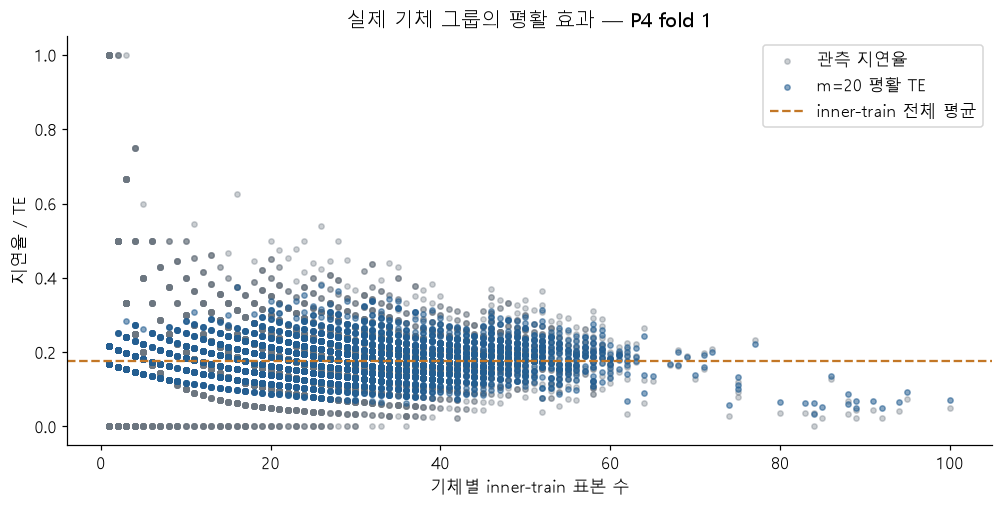

라벨 접근 경계: **204,000 outer-train → 163,200 inner-train + 40,800 holdout**. 외부 채점용 **51,001행**은 TE 적합에서 제외. Holdout 라벨 반전 시 TE 불변 검증 통과.

In [10]:
cfg=CVConfig(seed=42)
outer_tr,outer_va=make_folds(y4,cfg)[0]
Xt,yt=X4.iloc[outer_tr].reset_index(drop=True),y4.iloc[outer_tr].reset_index(drop=True)
it,ih=_make_inner_split(len(Xt),yt,cfg,0,None)
cols=['Tail_Number','Route','Origin_Airport','Destination_Airport','Airline']
te=oof_target_encode(Xt,yt,it,ih,cols=cols,m=20,inner_splits=5,seed=42)
te_cols=['TE_'+c for c in cols]
# 분할을 고정하고 holdout 라벨만 반전해 학습/holdout TE 불변성을 검사한다.
flipped=yt.copy(); flipped.iloc[ih]=1-flipped.iloc[ih]
again=oof_target_encode(Xt,flipped,it,ih,cols=cols,m=20,inner_splits=5,seed=42)
assert np.allclose(te.X_train[te_cols],again.X_train[te_cols])
assert np.allclose(te.X_valid[te_cols],again.X_valid[te_cols])
summary['te_scope']={'outer_train':len(outer_tr),'outer_valid':len(outer_va),
                     'inner_train':len(it),'inner_holdout':len(ih),'holdout_flip_invariant':True}
fit_keys=Xt.iloc[it].Tail_Number.reset_index(drop=True)
fit_y=yt.iloc[it].reset_index(drop=True)
groups=pd.DataFrame({'key':fit_keys,'y':fit_y}).groupby('key',observed=True).y.agg(['size','mean','sum'])
groups['smooth']=(groups['sum']+20*fit_y.mean())/(groups['size']+20)
table(groups.sort_values('size').head(12).reset_index().round(5),'te_small_groups')
fig,ax=plt.subplots(figsize=(9,4.5),layout='constrained')
ax.scatter(groups['size'],groups['mean'],s=12,alpha=.35,color=GREY,label='관측 지연율')
ax.scatter(groups['size'],groups['smooth'],s=12,alpha=.55,color=BLUE,label='m=20 평활 TE')
ax.axhline(fit_y.mean(),color=ORANGE,linestyle='--',label='inner-train 전체 평균')
ax.set(xlabel='기체별 inner-train 표본 수',ylabel='지연율 / TE',title='실제 기체 그룹의 평활 효과 — P4 fold 1')
ax.legend(); figure(fig,'05_te_smoothing')
display(Markdown(f"라벨 접근 경계: **{len(outer_tr):,} outer-train → {len(it):,} inner-train + {len(ih):,} holdout**. "
                 f"외부 채점용 **{len(outer_va):,}행**은 TE 적합에서 제외. Holdout 라벨 반전 시 TE 불변 검증 통과."))

## 10. 설명할 한계와 다음 검증
- P5 honest: student inner-train만 보는 teacher에서 pseudo-label을 만든다. 분위수 선별은 확률 보정이나 정확도 보장이 아니다. 이 노트북에서는 실행하지 않았다.
- P5 leaky는 고의 누수 대조군이다. 일반 성능 순위에 넣지 않는다.
- 시각 중앙값·Traffic·vocabulary는 타깃 비의존이지만 전체 피처 분포를 미리 보는 처리다. 실제 배포의 관측 가능 범위를 따로 정의해야 한다.
- 날씨(7-Ex)는 현재 기본 runner에서 제외된다. 기상 파일을 이 노트북에서 분석하지 않았으므로 과거 기상 결함 수치는 새 실측으로 주장하지 않는다.
- 컬럼 제거, 정오 대치, 시간대 proxy의 성능 효과는 동일한 새 프로토콜의 ablation 후 판단한다.

### 강사님 질문에 답하는 순서
1. “100만 행 중 라벨 유무와 피처 결측을 구분했습니다.”
2. “매핑 기반 대치의 전후 결측과 일대일 가정을 모두 확인했습니다.”
3. “시간 파싱·복원의 수식, 자정 보정, 남는 결측을 구분했습니다.”
4. “순환·Traffic·TE의 의미와 검증 라벨 접근 경계를 설명할 수 있습니다.”
5. “현재 구현의 가정과 검증되지 않은 성능 주장을 구분했습니다.”

In [11]:
checks={'행수보존':all(r['라벨행']+r['미라벨행']==N for r in feature_rows),
        '타깃분리':summary['labeled']+summary['unlabeled']==N,
        '복원건수일치':route_filled+global_filled==summary['duration_missing'],
        'holdout라벨_TE불변':True,'Traffic_단일그룹_독립검산':True}
assert all(checks.values())
summary['checks']=checks
(OUT/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
(OUT/'provenance.json').write_text(json.dumps(provenance,ensure_ascii=False,indent=2),encoding='utf-8')
sources=[]
for fn in [impute_cross,build_time_features,restore_time_missing,build_traffic_features,
           build_cyclic_features,encode_categoricals,oof_target_encode,build_features]:
    sources.append({'함수':fn.__name__,'파일':str(Path(inspect.getsourcefile(fn)).relative_to(ROOT)),
                    '시작행':inspect.getsourcelines(fn)[1]})
table(pd.DataFrame(sources),'source_locations')
display(Markdown('**검증 완료:** 원본·코드 지문과 계산 표를 output/preprocessing_review에 저장했다. '
                 '핵심 결과는 원본 전체에서 계산했고 모델 성능을 측정하지 않았다.'))

,함수,파일,시작행
0,impute_cross,src\features.py,152
1,build_time_features,src\features.py,210
2,restore_time_missing,src\features.py,249
3,build_traffic_features,src\features.py,328
4,build_cyclic_features,src\features.py,397
5,encode_categoricals,src\features.py,479
6,oof_target_encode,src\features.py,583
7,build_features,rerun_all_phases.py,275


**검증 완료:** 원본·코드 지문과 계산 표를 output/preprocessing_review에 저장했다. 핵심 결과는 원본 전체에서 계산했고 모델 성능을 측정하지 않았다.

## 11. 전처리 결정표와 발표용 요약 저장
아래 표는 위 실행 결과에서 생성한다. 현행 처리, 실측 변화, 남은 가정을 구분한다.
모델 코드나 기존 PLAN/AUDIT/진단 문서를 수정하지 않는다.

In [12]:
decisions = [
 ['타깃 결측', '미라벨로 분리; 0으로 대치하지 않음',
  f"라벨 {summary['labeled']:,} / 미라벨 {summary['unlabeled']:,}행",
  '음성 정답과 정답 미상을 구분', '라벨행의 대표성은 별도 검증', 'split_labeled'],
 ['클래스 불균형', 'spw 미사용; inner holdout에서 임계값 선택',
  f"라벨행 양성률 {summary['positive_rate_labeled']:.4%}",
  '확률 학습과 의사결정 임계값을 분리', '이 노트북은 임계값/모델 성능을 재측정하지 않음', 'run_fold_nested_grid'],
 ['공항→State 결측', '공항 코드의 첫 관측 State로 대치',
  f"정방향 충돌 키 {int(mapping.iloc[2]['충돌_키'])}/{int(mapping.iloc[4]['충돌_키'])}; 출발 State 잔여 {int(forward.Origin_State.isna().sum())}행 / 도착 State 잔여 {int(forward.Destination_State.isna().sum())}행",
  '관측 데이터의 일대일 대응 활용', 'State→공항 역방향은 다대일 역전이므로 일반적으로 안전하지 않음', 'impute_cross'],
 ['IATA→Airline 결측', '첫 관측 항공사명으로 대치 (현행)',
  f"{summary['airline_missing_before']:,} → {summary['airline_missing_after']:,}행; 충돌 키 {int(mapping.iloc[0]['충돌_키'])}개; 순서에 따라 {summary['airline_order_sensitive_rows']:,}행 변동",
  '연관 코드 활용 의도', '우선 수정 검토: 원천 사전 또는 충돌 없는 키만 대치. 최빈값도 정답 보장 아님', 'impute_cross'],
 ['HHMM 파싱', '시·분 분리; 미상 -1; 기본 strict=False',
  f"출발 엄격범위외 {time_checks[0]['엄격범위외']} / 도착 {time_checks[1]['엄격범위외']}행(2400: {time_checks[1]['2400_행']}행)",
  '100진 표기를 시간 계산 단위로 변환', '2400의 다음날 자정 의미를 원천 규약으로 확인; 무조건 오류 삭제 금지', 'build_time_features'],
 ['Duration 파생', '도착−출발; 음수면 +1440분',
  f"결측 {summary['duration_missing']:,}행; 0분 {summary['duration_zero']:,}행; 12시간 초과 {summary['duration_over_12h']:,}행",
  '시간차 정보 생성', '시간대 미보정으로 실제 비행시간 아님; 이상 후보를 자동 제거하지 않음', 'build_time_features'],
 ['Phase 6 시간 복원', 'Route 중앙값→전역 중앙값→단측 시각 역산',
  f"Route {route_filled:,} / 전역 {global_filled:,}행; 양측 시각 미상 {summary['hours_both_missing']:,}행 유지",
  '노선별 대표 시간차로 결측을 보완', '실제 시각을 복구했다고 단정 금지; 전체 데이터 적합의 배포 가정 명시', 'restore_time_missing'],
 ['Sin/Cos', 'Phase 4 NaN / Phase 6 남은 미상을 순환 피처에서 정오 취급',
  f"정오로 표현되는 미상 {summary['p6_noon_encoded_missing']:,}행",
  '23시와 0시의 인접성 표현', '정오 대치는 관측값 아님; NaN+missing flag 대안 비교 필요', 'build_cyclic_features'],
 ['Traffic', '월·일·공항·시각별 행 수; fixed는 -1 제외+flag',
  f"출발·도착 각각 {summary['hours_both_missing']:,}행 Traffic NaN; 정상 시간대 수치 동일",
  '시각 미상과 행 수를 분리', '표본 내 편수 proxy; 실제 전체 혼잡도 또는 다년 날짜를 보장하지 않음', 'build_traffic_features'],
 ['Speed proxy', 'Distance / (Duration + 1e-5)',
  f"최댓값 {summary['speed_proxy_max']:,.0f}",
  '거리와 시간차의 관계 표현', '우선 수정 검토: 0분 처리, 시간대·거리 단위 확인. 물리적 속도로 부르지 않음', 'build_features'],
 ['상수·ID·중복', 'Cancelled/Diverted/ID 제거; 중복 행 삭제 없음',
  f"상수 2개; ID 중복 {summary['duplicate_id']:,}, 완전 행 중복 {summary['duplicate_rows_exact']:,}",
  '상수와 레코드 식별자 제거', '피처 전체 일치와 같은 항공편 여부는 다름; 연도/편명 없이 운항 식별 확정 불가', 'prune_columns'],
 ['추가 컬럼 pruning', 'State·IATA·Day_of_Month·분 등 Phase별 제거',
  'phase_feature_inventory.csv에 10개 설정의 실제 기본 피처와 예상 TE 후 컬럼 기록',
  '중복·잡음 감소 가설', '기존 성능표로 효과를 입증할 수 없음; 새 프로토콜 ablation 필요', 'prune_columns'],
 ['범주형', 'MISSING 토큰→정수 코드→category dtype',
  '라벨+미라벨 vocabulary 공동 적합',
  '정수 크기 순서가 아닌 범주 분기', '새 배포 범주 처리 계약과 train-only vocabulary 비교 필요', 'encode_categoricals'],
 ['TE', 'inner-train OOF; holdout/outer-valid는 inner-train 라벨만 사용',
  f"P4 fold 1: {len(it):,}행 적합 / {len(ih):,}행 holdout; 라벨 반전 불변 통과",
  '그룹 지연율 평활 및 검증 정답 유입 차단', 'm=20의 최적성은 여기서 검증하지 않음', 'oof_target_encode'],
 ['Pseudo-label', 'honest teacher를 student inner-train 안에서 적합',
  '이번 노트북은 teacher/student 미학습',
  '미라벨 활용과 검증 독립성 유지', '분위수 선별은 고정 정확도를 의미하지 않음; leaky 대조군은 순위 제외', '_honest_pseudo_factory'],
]
decision_df = pd.DataFrame(decisions, columns=['항목','현행 처리','실측/코드 근거','처리 목적','한계·다음 검증','함수'])
decision_df.to_csv(OUT/'preprocessing_decisions.csv',index=False,encoding='utf-8-sig')
def md_table(frame):
    clean=lambda x:str(x).replace('|','/').replace('\n',' ')
    return '\n'.join(['| '+' | '.join(frame.columns)+' |','| '+' | '.join(['---']*len(frame.columns))+' |']+
                      ['| '+' | '.join(clean(x) for x in row)+' |' for row in frame.itertuples(index=False,name=None)])
text = f"""# 전처리 결정표 — 강사 설명용

## 먼저 설명할 결론

- 원본 {N:,}행 × {raw.shape[1]}열을 전수 진단했다. 라벨 {summary['labeled']:,}행의 지연율은 {summary['positive_rate_labeled']:.4%}다.
- Airline 대치는 결측을 줄이지만 행 순서에 따라 {summary['airline_order_sensitive_rows']:,}행의 결과가 달라진다. 일대일 매핑 가정은 성립하지 않는다.
- Duration 결측 {summary['duration_missing']:,}행은 중앙값으로 채울 수 있지만, 양쪽 시각이 미상인 {summary['hours_both_missing']:,}행의 실제 시각을 알아낸 것은 아니다.
- 0분 Duration {summary['duration_zero']:,}행과 Speed proxy 최댓값 {summary['speed_proxy_max']:,.0f}는 추가 처리 검토 대상이다.
- 전처리 효과와 성능 개선은 구분한다. 모델 재학습/Phase 성능 비교를 하지 않았다.

## 처리별 결정과 증거

{md_table(decision_df.drop(columns=['함수']))}

## 실제 처리 순서

원본 → 교차 결측 대치 → Route → 시각·Duration → (Phase 6 복원·Traffic) → Sin/Cos·Speed proxy → pruning → 라벨/미라벨 분리 → category vocabulary → outer/inner 분할 → inner 경계 TE.

Teacher, 트리 수 선택, 임계값 선택은 후속 모델링이며 이 노트북에서는 실행하지 않았다.
표준화·이상치 삭제·중복 삭제는 현재 공통 처리에 없다. LightGBM을 쓰는 설계상 스케일링을 생략했지만, 다른 모델에 그대로 적용 가능한 전처리라고 일반화하지 않는다.

## 강사님께 보여줄 자료 순서

1. [실행된 노트북](../notebooks/preprocessing_walkthrough.ipynb) 또는 [HTML 보기](preprocessing_walkthrough.html)의 원본 결측/라벨 구성을 설명한다.
2. 결측 대치 전후 숫자와 IATA 매핑 충돌을 함께 보여준다. 결측률 감소만으로 정답 복원을 주장하지 않는다.
3. 실제 행의 HHMM 변환, 자정 보정, Route 복원과 남은 시각 미상을 설명한다.
4. Traffic 미상 버킷과 TE 평활 그림으로 피처의 의미를 설명한다.
5. 검증 라벨을 바꿔도 TE가 변하지 않는 실행 검사를 보여준다.

## 다음 개선 우선순위 (이번에는 학습 코드 미수정)

1. IATA→Airline: 충돌 키에서 첫 행을 고르는 대치 제거 검토. 실제 코드 사전 또는 검증 가능한 복합 키가 필요하다. 모르면 결측을 유지하는 대안도 비교한다.
2. Duration/Speed: 0분 및 시간대 미보정의 처리 정책을 먼저 정의한다. 2400은 원천 규약 확인 후 정규화한다.
3. Phase 6 순환 피처: 미상을 정오와 합치는 대신 NaN/결측 플래그를 쓰는 대안을 비교한다.
4. 중앙값·Traffic·vocabulary: 실제 예측 시점에 이용 가능한 데이터 범위를 정의한다. 타깃 비의존과 배포 가용성은 서로 다른 조건이다.
5. 이후 승인된 새 프로토콜로 하나씩 바꿔 효과를 비교한다. 과거 Phase 표는 성능 근거로 재사용하지 않는다.

## 근거와 재현

원본: data/train.csv. SHA256: `{provenance['sha256']}`.
실행 시각(UTC): {provenance['executed_utc']}.
원본 기간은 Month=1~12이나 연도/시간대는 파일만으로 확정하지 않았다.
전체 컬럼 사전, 매핑 충돌, 시간 복원, Phase 컬럼 목록, 계산 검사는 [근거 폴더](preprocessing_review/)에 저장했다.
[source_locations.csv](preprocessing_review/source_locations.csv)는 실행 시점 함수의 파일·시작행,
[provenance.json](preprocessing_review/provenance.json)은 코드 지문과 패키지 버전을 담는다.
원본·PLAN·README·AUDIT 및 기존 진단 결과는 변경하지 않았다.
"""
(ROOT/'output/preprocessing_decisions.md').write_text(text,encoding='utf-8')
display(Markdown('결정표 저장: **output/preprocessing_decisions.md** (15개 처리 항목).'))

결정표 저장: **output/preprocessing_decisions.md** (15개 처리 항목).